### Dataset

Source: https://www.kaggle.com/datasets/bofulee/kevin-hillstrom-minethatdata-e-mailanalytics

Donated by: BOFU-LEE

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score
from scipy.stats import chi2_contingency
from sklift.models import TwoModels, ClassTransformation
from sklift.metrics import qini_auc_score, uplift_by_percentile

df = pd.read_csv("cust-uplift.csv")
print(df.shape)
print(df.columns.tolist())
df.head()

(64000, 12)
['recency', 'history_segment', 'history', 'mens', 'womens', 'zip_code', 'newbie', 'channel', 'segment', 'visit', 'conversion', 'spend']


,recency,history_segment,history,mens,womens,zip_code,newbie,channel,segment,visit,conversion,spend
0,10,2) $100 - $200,142.44,1,0,Surburban,0,Phone,Womens E-Mail,0,0,0.0
1,6,3) $200 - $350,329.08,1,1,Rural,1,Web,No E-Mail,0,0,0.0
2,7,2) $100 - $200,180.65,0,1,Surburban,1,Web,Womens E-Mail,0,0,0.0
3,9,5) $500 - $750,675.83,1,0,Rural,1,Web,Mens E-Mail,0,0,0.0
4,2,1) $0 - $100,45.34,1,0,Urban,0,Web,Womens E-Mail,0,0,0.0


In [6]:
def prepare_binary_data(df, treatment_label, control_label="No E-Mail"): #Filter to one campaign vs control, and build the treatment column.
    data = df[df['segment'].isin([treatment_label, control_label])].copy()
    data['treatment'] = (data['segment'] == treatment_label).astype(int)
    return data

def build_features(data): #Turn the raw columns into a clean feature matrix, target, and treatment flag.
    feature_cols = [c for c in data.columns
                    if c not in ['segment', 'treatment', 'visit', 'conversion', 'spend']]
    X = pd.get_dummies(data[feature_cols], drop_first=True)
    y = data['conversion']
    treatment = data['treatment']
    return X, y, treatment

def evaluate_uplift_model(X, y, treatment, label=""): #Split, scale, fit a T-Learner, and report a properly held out Qini AUC.
    X_train, X_test, y_train, y_test, trmnt_train, trmnt_test = train_test_split(
        X, y, treatment, test_size=0.3, random_state=42, stratify=treatment
    )

    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    baseline = RandomForestClassifier(random_state=42)
    baseline.fit(X_train_scaled, y_train)
    baseline_preds = baseline.predict_proba(X_test_scaled)[:, 1]
    baseline_auc = roc_auc_score(y_test, baseline_preds)

    tm = TwoModels(
        estimator_trmnt=RandomForestClassifier(random_state=42),
        estimator_ctrl=RandomForestClassifier(random_state=42),
        method='vanilla'
    )
    tm.fit(X_train_scaled, y_train, trmnt_train)
    uplift_preds = tm.predict(X_test_scaled)
    qini = qini_auc_score(y_test, uplift_preds, trmnt_test)

    print(f"--- {label} ---")
    print(f"Baseline AUC (ignoring treatment): {baseline_auc:.4f}")
    print(f"Qini AUC (held out test set): {qini:.4f}")

    return {
        "model": tm, "scaler": scaler,
        "X_test": X_test, "y_test": y_test, "trmnt_test": trmnt_test,
        "uplift_preds": uplift_preds, "qini": qini
    }

# Women's Email

In [7]:
women_data = prepare_binary_data(df, "Womens E-Mail")
print(women_data['treatment'].value_counts())
print(women_data['conversion'].value_counts())

X_women, y_women, trmnt_women = build_features(women_data)
women_results = evaluate_uplift_model(X_women, y_women, trmnt_women, label="Women's Email")

treatment
1    21387
0    21306
Name: count, dtype: int64
conversion
0    42382
1      311
Name: count, dtype: int64
--- Women's Email ---
Baseline AUC (ignoring treatment): 0.5166
Qini AUC (held out test set): 0.0703


# Men's Email

In [8]:
men_data = prepare_binary_data(df, "Mens E-Mail")
print(men_data['treatment'].value_counts())
print(men_data['conversion'].value_counts())

X_men, y_men, trmnt_men = build_features(men_data)
men_results = evaluate_uplift_model(X_men, y_men, trmnt_men, label="Men's Email")

treatment
1    21307
0    21306
Name: count, dtype: int64
conversion
0    42224
1      389
Name: count, dtype: int64
--- Men's Email ---
Baseline AUC (ignoring treatment): 0.5220
Qini AUC (held out test set): -0.0022


# Qini Curve

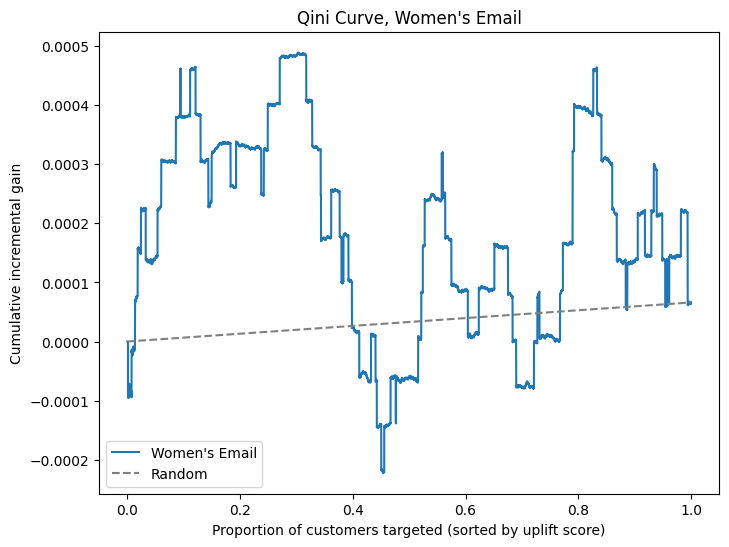

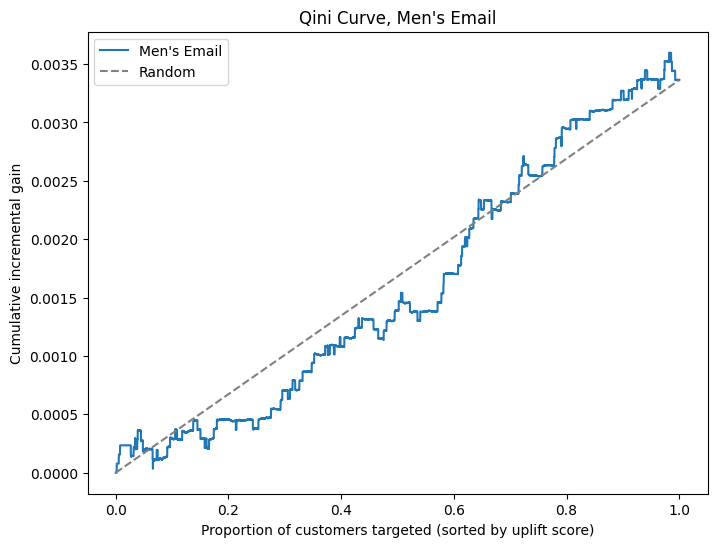

In [9]:
def plot_qini_curve(y_test, uplift_preds, trmnt_test, label):
    sorted_idx = np.argsort(-uplift_preds)
    y_sorted = y_test.values[sorted_idx]
    trmnt_sorted = trmnt_test.values[sorted_idx]

    n = len(y_sorted)
    x_vals = np.arange(1, n + 1) / n

    cum_treated_resp = np.cumsum(y_sorted * trmnt_sorted)
    cum_control_resp = np.cumsum(y_sorted * (1 - trmnt_sorted))
    cum_treated_n = np.cumsum(trmnt_sorted)
    cum_control_n = np.cumsum(1 - trmnt_sorted)

    qini_gain = cum_treated_resp - cum_control_resp * (cum_treated_n / cum_control_n.clip(min=1))
    qini_gain_normalized = qini_gain / n

    plt.figure(figsize=(8, 6))
    plt.plot(x_vals, qini_gain_normalized, label=label)
    plt.plot([0, 1], [0, qini_gain_normalized[-1]], linestyle='--', color='gray', label='Random')
    plt.xlabel("Proportion of customers targeted (sorted by uplift score)")
    plt.ylabel("Cumulative incremental gain")
    plt.title(f"Qini Curve, {label}")
    plt.legend()
    plt.show()

plot_qini_curve(women_results['y_test'], women_results['uplift_preds'], women_results['trmnt_test'], "Women's Email")
plot_qini_curve(men_results['y_test'], men_results['uplift_preds'], men_results['trmnt_test'], "Men's Email")

### Aggregate campaign effect, using the full dataset for maximum statistical power

In [10]:
def check_aggregate_effect(data, label):
    treatment_conv = data[data['treatment'] == 1]['conversion'].sum()
    treatment_n = len(data[data['treatment'] == 1])
    control_conv = data[data['treatment'] == 0]['conversion'].sum()
    control_n = len(data[data['treatment'] == 0])

    table = [
        [treatment_conv, treatment_n - treatment_conv],
        [control_conv, control_n - control_conv]
    ]
    chi2, p_value, dof, expected = chi2_contingency(table)

    treatment_rate = treatment_conv / treatment_n
    control_rate = control_conv / control_n
    relative_lift = (treatment_rate - control_rate) / control_rate * 100

    print(f"--- {label} ---")
    print(f"Treatment: {treatment_conv}/{treatment_n} converted ({treatment_rate:.4%})")
    print(f"Control: {control_conv}/{control_n} converted ({control_rate:.4%})")
    print(f"Relative lift: {relative_lift:.1f}%")
    print(f"p-value: {p_value:.4f}")

check_aggregate_effect(women_data, "Women's Email")
check_aggregate_effect(men_data, "Men's Email")

--- Women's Email ---
Treatment: 189/21387 converted (0.8837%)
Control: 122/21306 converted (0.5726%)
Relative lift: 54.3%
p-value: 0.0002
--- Men's Email ---
Treatment: 267/21307 converted (1.2531%)
Control: 122/21306 converted (0.5726%)
Relative lift: 118.8%
p-value: 0.0000


### Newbie versus returning customer breakdown, using the held out test set

In [11]:
def check_newbie_split(results, data, label):
    test_df = data.loc[results['X_test'].index].copy()
    test_df['uplift_score'] = results['uplift_preds']

    treated_test = test_df[test_df['treatment'] == 1]
    summary = treated_test.groupby(['newbie', treated_test['uplift_score'] > 0])['conversion'].mean()

    print(f"--- {label}, held out test set only ---")
    print(summary)

check_newbie_split(women_results, women_data, "Women's Email")
check_newbie_split(men_results, men_data, "Men's Email")

--- Women's Email, held out test set only ---
newbie  uplift_score
0       False           0.005140
        True            0.013793
1       False           0.006647
        True            0.007286
Name: conversion, dtype: float64
--- Men's Email, held out test set only ---
newbie  uplift_score
0       False           0.014636
        True            0.015919
1       False           0.011399
        True            0.011129
Name: conversion, dtype: float64


### Final targeting list for deployment

In [12]:
def build_targeting_list(X, y, treatment, data, label):
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    final_model = TwoModels(
        estimator_trmnt=RandomForestClassifier(random_state=42),
        estimator_ctrl=RandomForestClassifier(random_state=42),
        method='vanilla'
    )
    final_model.fit(X_scaled, y, treatment)
    uplift_scores = final_model.predict(X_scaled)

    targeting_df = data.copy()
    targeting_df['uplift_score'] = uplift_scores
    targeting_df = targeting_df.sort_values('uplift_score', ascending=False).reset_index(drop=True)

    strong_targets = targeting_df[targeting_df['uplift_score'] > 0].copy()
    returning = strong_targets[strong_targets['newbie'] != 1]
    new_customers = strong_targets[strong_targets['newbie'] == 1]

    print(f"--- {label} targeting list ---")
    print(f"Total customers with positive predicted uplift: {len(strong_targets)}")
    print(f"Returning customers: {len(returning)}")
    print(f"New customers: {len(new_customers)}")

    return targeting_df, returning, new_customers

women_targeting_df, women_returning, women_new = build_targeting_list(
    X_women, y_women, trmnt_women, women_data, "Women's Email"
)

men_targeting_df, men_returning, men_new = build_targeting_list(
    X_men, y_men, trmnt_men, men_data, "Men's Email"
)

women_returning.to_csv('recommended_targets_womens_returning.csv', index=False)
men_returning.to_csv('recommended_targets_mens_returning.csv', index=False)

--- Women's Email targeting list ---
Total customers with positive predicted uplift: 5448
Returning customers: 2490
New customers: 2958
--- Men's Email targeting list ---
Total customers with positive predicted uplift: 7518
Returning customers: 3819
New customers: 3699


**Final Recommendation**

- Both the Women's and Men's email campaigns produce a real, statistically significant lift in conversion when measured on the full dataset.
- The Men's campaign has the stronger effect, roughly double the relative lift of the Women's campaign, making it the better overall performer.
- The Women's model, evaluated on a genuine held out test set, shows a small but real positive Qini AUC, meaning it does a bit better than random at telling apart customers who respond because of the email from those who would have converted anyway.
- The Men's model, evaluated the same honest way, shows a negative Qini AUC, meaning its ranking of customers is actually worse than picking people at random.
- Both campaigns should continue running, since each has a proven positive effect.
- The Men's campaign should get priority for budget given its stronger return, and it should go out to the full eligible list rather than being filtered, since there is no reliable evidence pointing to who benefits more within that group.
- The Women's campaign can be sent more selectively, targeting the returning customers identified with a positive predicted uplift score, since this is the group with the clearest supporting evidence.
- New customers, for both campaigns, should keep receiving their respective email without filtering, since the data does not yet support singling anyone out within that group.
- Going forward, adding features around actual email engagement, such as past opens or clicks, would likely improve targeting reliability for both campaigns, and could be what moves the Men's campaign from unreliable to usable for targeting.